In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns

## 0. Metadata Analysis

In [ ]:
df_sra = pd.read_csv(Path("../PRJNA269994.SraRunTable.csv"))
df_sra.shape

(346, 35)

In [3]:
df_sra.head()

,Run,AGE,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,BioSampleModel,Bytes,Center Name,...,Organism,Platform,ReleaseDate,Sample Name,SRA Study,tissue,create_date,version,Cultivar,Ecotype
0,SRR1946602,3-5 weeks,WGA,52,42649984,PRJNA269994,SAMN03268092,Plant,33781592,UC DAVIS GENOME CENTER,...,Arabidopsis thaliana,ILLUMINA,2015-05-14T00:00:00Z,FRAG00026,SRP051357,Leaf,2015-04-13T14:49:00Z,1.0,Col-0 x Ler,NaN
1,SRR1970924,3-5 weeks,WGA,50,132288100,PRJNA269994,SAMN03462528,Plant,88514585,UC DAVIS GENOME CENTER,...,Arabidopsis thaliana,ILLUMINA,2015-05-14T00:00:00Z,FRAG00699,SRP051357,Leaf,2015-04-13T16:31:00Z,1.0,NaN,Col-0
2,SRR1970925,3-5 weeks,WGA,50,129439850,PRJNA269994,SAMN03462529,Plant,86608559,UC DAVIS GENOME CENTER,...,Arabidopsis thaliana,ILLUMINA,2015-05-14T00:00:00Z,FRAG00700,SRP051357,Leaf,2015-04-13T16:31:00Z,1.0,NaN,Col-0
3,SRR1970926,3-5 weeks,WGA,50,180865550,PRJNA269994,SAMN03462530,Plant,120559935,UC DAVIS GENOME CENTER,...,Arabidopsis thaliana,ILLUMINA,2015-05-14T00:00:00Z,FRAG00701,SRP051357,Leaf,2015-04-13T16:32:00Z,1.0,NaN,Col-0
4,SRR1970927,3-5 weeks,WGA,50,81186550,PRJNA269994,SAMN03462531,Plant,54624546,UC DAVIS GENOME CENTER,...,Arabidopsis thaliana,ILLUMINA,2015-05-14T00:00:00Z,FRAG00702,SRP051357,Leaf,2015-04-13T16:31:00Z,1.0,NaN,Col-0


In [4]:
df_sra_filtered = df_sra[pd.to_numeric(df_sra["Sample Name"].str.slice(4)).between(1160, 1255, inclusive='both')]
df_sra_filtered.shape

(96, 35)

In [5]:
# Drop columns that contain only a single unique value
unique_counts = df_sra_filtered.nunique()
cols_to_drop = unique_counts[unique_counts == 1].index
df_sra_filtered.drop(columns=cols_to_drop, inplace=True)
df_sra_filtered

/tmp/ipykernel_624300/2700239712.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sra_filtered.drop(columns=cols_to_drop, inplace=True)


,Run,Bases,BioSample,Bytes,DATASTORE filetype,DATASTORE provider,DATASTORE region,Experiment,label,Library Name,Sample Name,create_date,Cultivar
6,SRR1970929,48991200,SAMN03462533,31977552,"sra,run.zq,fastq","gs,ncbi,s3","s3.us-east-1,ncbi.public,gs.us-east1",SRX992704,FRAG01160,FRAG01160A,FRAG01160,2015-04-13T16:30:00Z,NaN
7,SRR1970952,76700800,SAMN03462556,49799239,"fastq,sra,run.zq","s3,gs,ncbi","s3.us-east-1,ncbi.public,gs.us-east1",SRX992727,FRAG01183,FRAG01183A,FRAG01183,2015-04-13T16:03:00Z,NaN
8,SRR1970953,35293250,SAMN03462557,23112942,"run.zq,sra,fastq","gs,ncbi,s3","ncbi.public,s3.us-east-1,gs.us-east1",SRX992728,FRAG01184,FRAG01184A,FRAG01184,2015-04-13T16:03:00Z,NaN
9,SRR1970954,58820800,SAMN03462558,38455814,"sra,fastq,run.zq","ncbi,gs,s3","gs.us-east1,s3.us-east-1,ncbi.public",SRX992729,FRAG01185,FRAG01185A,FRAG01185,2015-04-13T16:04:00Z,NaN
10,SRR1970955,38273300,SAMN03462559,25080998,"fastq,run.zq,sra","s3,gs,ncbi","gs.us-east1,s3.us-east-1,ncbi.public",SRX992730,FRAG01186,FRAG01186A,FRAG01186,2015-04-13T16:04:00Z,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,SRR1970987,13925400,SAMN03462591,9211695,"run.zq,fastq,sra","ncbi,s3,gs","gs.us-east1,s3.us-east-1,ncbi.public",SRX992762,FRAG01218,FRAG01218A,FRAG01218,2015-04-13T16:00:00Z,NaN
298,SRR1970988,49571750,SAMN03462592,32236769,"run.zq,sra,fastq","s3,ncbi,gs","s3.us-east-1,ncbi.public,gs.us-east1",SRX992763,FRAG01219,FRAG01219A,FRAG01219,2015-04-13T16:00:00Z,NaN
299,SRR1970989,38602750,SAMN03462593,25183296,"fastq,sra,run.zq","s3,ncbi,gs","ncbi.public,s3.us-east-1,gs.us-east1",SRX992764,FRAG01220,FRAG01220A,FRAG01220,2015-04-13T16:00:00Z,NaN
300,SRR1970990,30937050,SAMN03462594,20226089,"fastq,run.zq,sra","s3,gs,ncbi","s3.us-east-1,ncbi.public,gs.us-east1",SRX992765,FRAG01221,FRAG01221A,FRAG01221,2015-04-13T16:00:00Z,NaN


In [6]:
df_sra_filtered['Coverage'] = df_sra_filtered['Bases'] / 133_917_231

/tmp/ipykernel_624300/363552689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sra_filtered['Coverage'] = df_sra_filtered['Bases'] / 133_917_231


<Axes: >

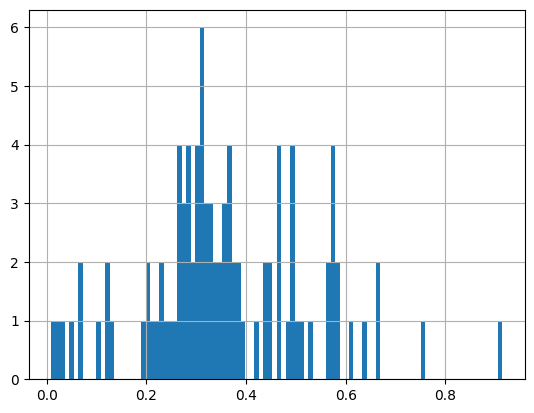

In [7]:
df_sra_filtered['Coverage'].hist(bins=100)

In [10]:
df_sra_2x_filtered = df_sra_filtered[df_sra_filtered["Coverage"].between(0.25, 0.75)]
df_sra_2x_filtered.shape

(76, 14)

## 1.

In [2]:
df = pd.read_feather("../data/tailswap/joined-counts/tailswap-joined-counts.feather")
df.shape

(1963506, 75)

In [3]:
df.head()

,SRR1970938,SRR1970966,SRR1970973,SRR1970997,SRR1970945,SRR1971004,SRR1971016,SRR1970946,SRR1970988,SRR1970949,...,SRR1971005,SRR1970978,SRR1970941,SRR1970944,SRR1970953,SRR1971017,SRR1970985,SRR1970970,SRR1971023,SRR1970979
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAAAAAAAAAAAAAAAAAAAA,5776.509277,5777.261719,5551.745605,6271.102539,5487.721191,5254.735840,5545.995605,4908.103027,5891.934082,5158.458984,...,5363.606445,5303.379883,4429.627930,5604.759766,6109.007812,4836.383789,5040.512207,4865.124023,5934.486328,5925.310059
AAAAAAAAAAAAAAAAAAAAAAC,508.623474,602.680908,508.258423,597.644958,546.121033,495.691315,588.394531,490.615601,615.938110,518.247009,...,519.187500,589.264465,487.027161,501.152771,588.134277,457.719330,495.219299,462.255432,489.604980,567.927612
AAAAAAAAAAAAAAAAAAAAAAG,263.394287,214.234238,203.303360,205.701065,222.690140,281.503723,208.201126,210.263840,197.208252,212.101089,...,203.681259,231.300064,195.473495,252.085892,223.870468,220.587631,205.027100,210.532181,232.957214,258.335297
AAAAAAAAAAAAAAAAAAAAAAT,145.320999,138.899124,143.354935,119.528999,145.809021,136.672089,168.974838,140.175888,159.387482,170.081070,...,135.787506,151.446472,109.332626,172.082581,144.187759,151.653992,138.787567,105.266090,165.833954,178.374374
AAAAAAAAAAAAAAAAAAAAACA,272.476868,289.569336,271.071167,280.754150,243.898712,257.025116,292.688538,251.148468,313.372009,286.136383,...,259.593750,250.575073,274.988129,267.180847,337.702911,259.190460,217.644150,219.685745,244.802490,289.089508
